# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [21]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [22]:
# Import essential libraries
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Load the dataset.

In [23]:
# Load and unzip the dataset
workspace_dir = Path('.')
zip_files = list(workspace_dir.glob('*.zip'))

if zip_files:
    zip_path = zip_files[0]
    print(f"Zip file found: {zip_path.name}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(workspace_dir)
    print("Dataset extracted successfully.")
else:
    print("No zip file found in workspace. Proceeding with existing folder structure.")

data_dir = Path('data')
if not data_dir.exists():
    raise FileNotFoundError("'data' directory not found. Ensure dataset is extracted in the notebook folder.")

print(f"Dataset directory: {data_dir.resolve()}")
print("Classes:", sorted([d.name for d in data_dir.iterdir() if d.is_dir()]))

No zip file found in workspace. Proceeding with existing folder structure.
Dataset directory: /Users/I557930/Documents/CNN/data
Classes: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [24]:
# Create a function to load the raw images
def load_images_from_directory(root_dir, valid_exts=('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
    images = []
    labels = []
    paths = []
    dimensions = []
    unreadable_files = []

    root_dir = Path(root_dir)
    class_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir()])

    for class_dir in class_dirs:
        for file_path in class_dir.rglob('*'):
            if file_path.suffix.lower() in valid_exts:
                try:
                    with Image.open(file_path) as img:
                        rgb_img = img.convert('RGB')
                        arr = np.array(rgb_img)
                        images.append(arr)
                        labels.append(class_dir.name)
                        paths.append(str(file_path))
                        dimensions.append(rgb_img.size)  # (width, height)
                except Exception as e:
                    unreadable_files.append((str(file_path), str(e)))

    return images, labels, paths, dimensions, unreadable_files

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [25]:
# Get the images and their labels
raw_images, labels, image_paths, image_dims, unreadable_files = load_images_from_directory(data_dir)

valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
all_image_files = [
    p for p in data_dir.rglob('*') if p.is_file() and p.suffix.lower() in valid_exts
]

print(f"Total image files discovered: {len(all_image_files)}")
print(f"Total images loaded: {len(raw_images)}")
print(f"Unreadable image files: {len(unreadable_files)}")
print(f"Total labels loaded: {len(labels)}")

if len(raw_images) == 0:
    raise ValueError("No images were loaded. Check dataset path and supported image extensions.")

if len(raw_images) + len(unreadable_files) != len(all_image_files):
    raise ValueError("Mismatch between discovered files and processed files.")

print("Sample label counts:")
print(pd.Series(labels).value_counts())
print(f"First image shape: {raw_images[0].shape}")
print(f"First image path: {image_paths[0]}")

Total image files discovered: 7625
Total images loaded: 7625
Unreadable image files: 0
Total labels loaded: 7625
Sample label counts:
Plastic       2295
Paper         1030
Other         1010
Food_Waste    1000
Metal         1000
Glass          750
Cardboard      540
Name: count, dtype: int64
First image shape: (256, 256, 3)
First image path: data/Cardboard/file_207.png


Perform any operations, if needed, on the images and labels to get them into the desired format.

In [26]:
# Data quality checks and interpretation of variables
print("Variable meanings:")
print("raw_images: list of RGB image arrays")
print("labels: class names corresponding to each image")
print("image_paths: file paths for traceability")
print("image_dims: original image dimensions as (width, height)")

if 'unreadable_files' not in globals():
    unreadable_files = []

quality_report = {
    'total_images_loaded': len(raw_images),
    'total_labels_loaded': len(labels),
    'missing_labels': int(pd.Series(labels).isna().sum()),
    'duplicate_image_paths': int(pd.Series(image_paths).duplicated().sum()),
    'unreadable_images': len(unreadable_files),
    'class_imbalance_ratio': round(pd.Series(labels).value_counts().max() / pd.Series(labels).value_counts().min(), 2)
}

print("\nData quality report:")
for k, v in quality_report.items():
    print(f"{k}: {v}")

dim_df = pd.DataFrame(image_dims, columns=['width', 'height'])
print("\nImage dimension summary:")
print(dim_df.describe())

# Flag potential outliers in dimensions using IQR rule
for col in ['width', 'height']:
    q1 = dim_df[col].quantile(0.25)
    q3 = dim_df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((dim_df[col] < lower) | (dim_df[col] > upper)).sum()
    print(f"{col}_outliers: {outliers}")

Variable meanings:
raw_images: list of RGB image arrays
labels: class names corresponding to each image
image_paths: file paths for traceability
image_dims: original image dimensions as (width, height)

Data quality report:
total_images_loaded: 7625
total_labels_loaded: 7625
missing_labels: 0
duplicate_image_paths: 0
unreadable_images: 0
class_imbalance_ratio: 4.25

Image dimension summary:
        width  height
count  7625.0  7625.0
mean    256.0   256.0
std       0.0     0.0
min     256.0   256.0
25%     256.0   256.0
50%     256.0   256.0
75%     256.0   256.0
max     256.0   256.0
width_outliers: 0
height_outliers: 0


### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

/var/folders/sw/st03p4h57p17nt65h1s6zxfw0000gn/T/ipykernel_27625/1331937729.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


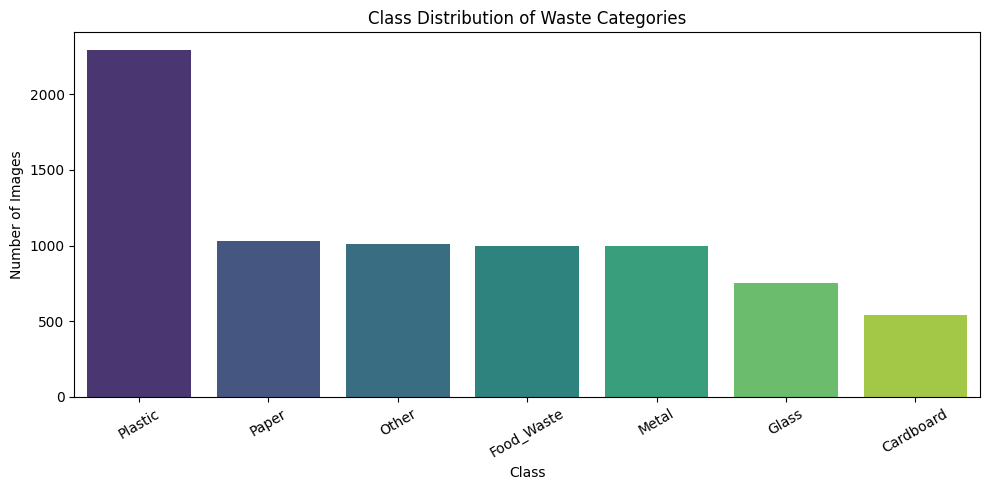

In [27]:
# Visualise Data Distribution
class_counts = pd.Series(labels).value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution of Waste Categories')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

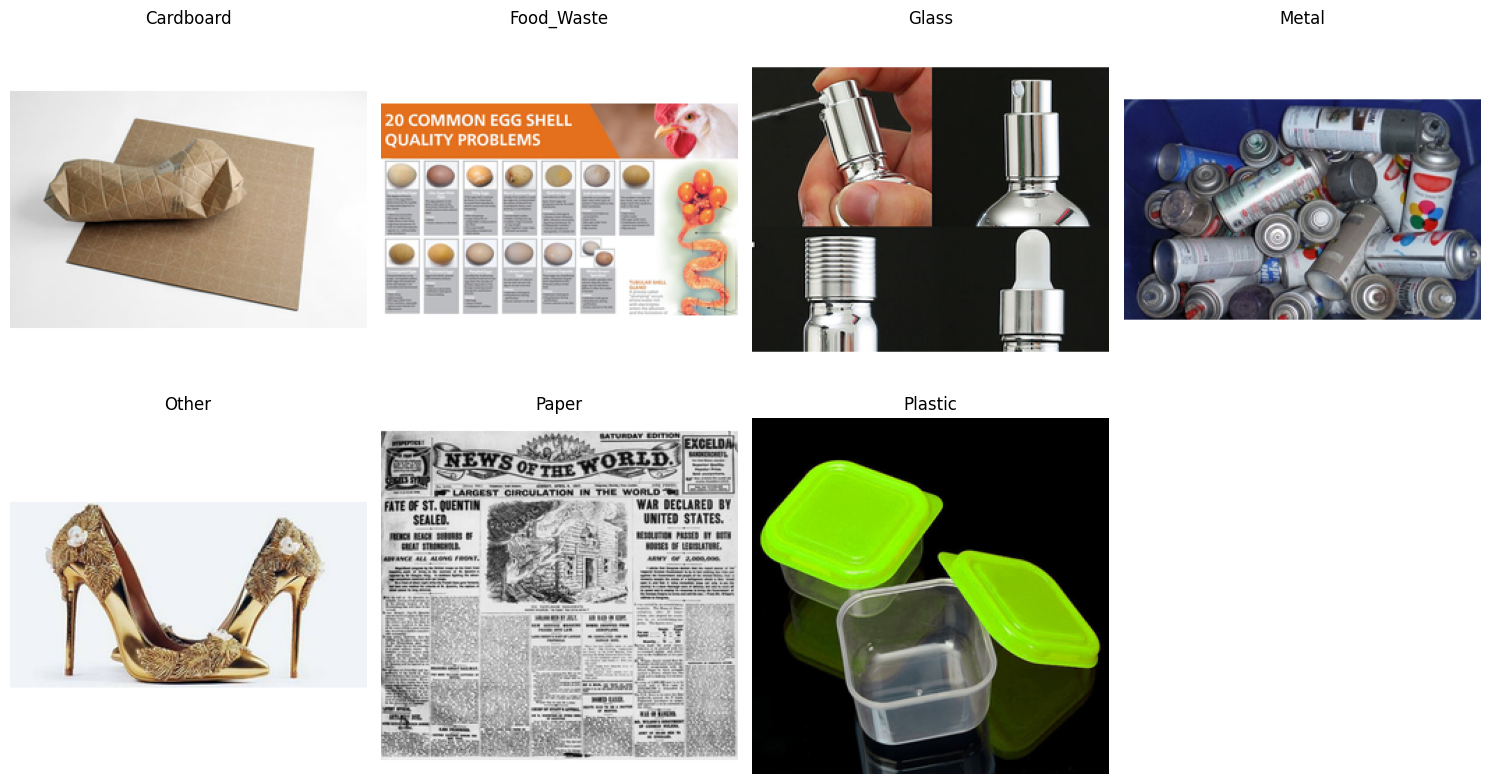

In [28]:
# Visualise Sample Images (across different labels)
unique_classes = sorted(set(labels))
samples_per_class = 1

plt.figure(figsize=(15, 8))
plot_idx = 1
for class_name in unique_classes:
    class_indices = [i for i, lbl in enumerate(labels) if lbl == class_name]
    chosen_indices = np.random.choice(class_indices, size=samples_per_class, replace=False)

    for idx in chosen_indices:
        plt.subplot(2, 4, plot_idx)
        plt.imshow(raw_images[idx])
        plt.title(class_name)
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [29]:
# Find the smallest and largest image dimensions from the data set
widths = [w for (w, h) in image_dims]
heights = [h for (w, h) in image_dims]

min_w, max_w = min(widths), max(widths)
min_h, max_h = min(heights), max(heights)

print(f"Smallest image size (W x H): {min_w} x {min_h}")
print(f"Largest image size (W x H): {max_w} x {max_h}")

# Choose a practical common resize dimension balancing detail and compute
target_size = (128, 128)
print(f"Chosen resize dimension: {target_size}")

Smallest image size (W x H): 256 x 256
Largest image size (W x H): 256 x 256
Chosen resize dimension: (128, 128)


In [30]:
# Resize the image dimensions
X = np.array([np.array(Image.fromarray(img).resize(target_size)) for img in raw_images], dtype=np.float32)
X = X / 255.0

print("Resized image tensor shape:", X.shape)
print("Pixel value range:", (X.min(), X.max()))

Resized image tensor shape: (7625, 128, 128, 3)
Pixel value range: (0.0, 1.0)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [31]:
# Encode the labels suitably
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(labels)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

y = tf.keras.utils.to_categorical(y_int, num_classes=num_classes)

print("Class mapping:")
for idx, cls in enumerate(class_names):
    print(f"{idx}: {cls}")

print("Encoded labels shape:", y.shape)

Class mapping:
0: Cardboard
1: Food_Waste
2: Glass
3: Metal
4: Other
5: Paper
6: Plastic
Encoded labels shape: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [32]:
# Assign specified parts of the dataset to train and validation sets
# First split: train (70%) and temp (30%)
X_train, X_temp, y_train_int, y_temp_int = train_test_split(
    X, y_int, test_size=0.30, random_state=SEED, stratify=y_int
)

# Second split: validation (15%) and test (15%) from temp
X_val, X_test, y_val_int, y_test_int = train_test_split(
    X_temp, y_temp_int, test_size=0.50, random_state=SEED, stratify=y_temp_int
)

# One-hot encoding for model training
y_train = tf.keras.utils.to_categorical(y_train_int, num_classes=num_classes)
y_val = tf.keras.utils.to_categorical(y_val_int, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test_int, num_classes=num_classes)

# tf.data batch datasets for efficient model input pipelines
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Batched datasets created:")
print(train_ds)
print(val_ds)
print(test_ds)

Train shape: (5337, 128, 128, 3) (5337, 7)
Validation shape: (1144, 128, 128, 3) (1144, 7)
Test shape: (1144, 128, 128, 3) (1144, 7)
Batched datasets created:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float64, name=None))>


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [33]:
# Build and compile the model
input_shape = (target_size[1], target_size[0], 3)

def build_simple_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.35),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.40),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_vgg_like_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Dropout(0.30),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Dropout(0.35),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.40),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Two architecture options for experimentation
simple_cnn = build_simple_cnn(input_shape, num_classes)
vgg_like_cnn = build_vgg_like_cnn(input_shape, num_classes)

# Select model to train in this run
model_name = 'simple_cnn'
model = simple_cnn if model_name == 'simple_cnn' else vgg_like_cnn
print(f"Selected model: {model_name}")
model.summary()

Selected model: simple_cnn


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,807 (32.37 MB)

 Trainable params: 8,484,359 (32.37 MB)

 Non-trainable params: 448 (1.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

Class weights: {0: 2.0170068027210886, 1: 1.0891836734693878, 2: 1.4522448979591838, 3: 1.0891836734693878, 4: 1.078399676702364, 5: 1.0574598771547454, 6: 0.4747375911759473}
Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.2071 - loss: 46.9822 - val_accuracy: 0.0970 - val_loss: 17.3878 - learning_rate: 0.0010
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.2760 - loss: 39.2759 - val_accuracy: 0.2570 - val_loss: 17.1402 - learning_rate: 0.0010
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.2845 - loss: 37.9085 - val_accuracy: 0.3121 - val_loss: 15.0106 - learning_rate: 0.0010
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.3339 - loss: 27.0910 - val_accuracy: 0.3523 - val_loss: 11.8409 - learning_rate: 0.0010
Epoch 5/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.3339 - loss: 20.7102 - val_accuracy: 0.4003 - val_loss: 9.1594 - learning_rate: 0.0010
Epoch 6/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1

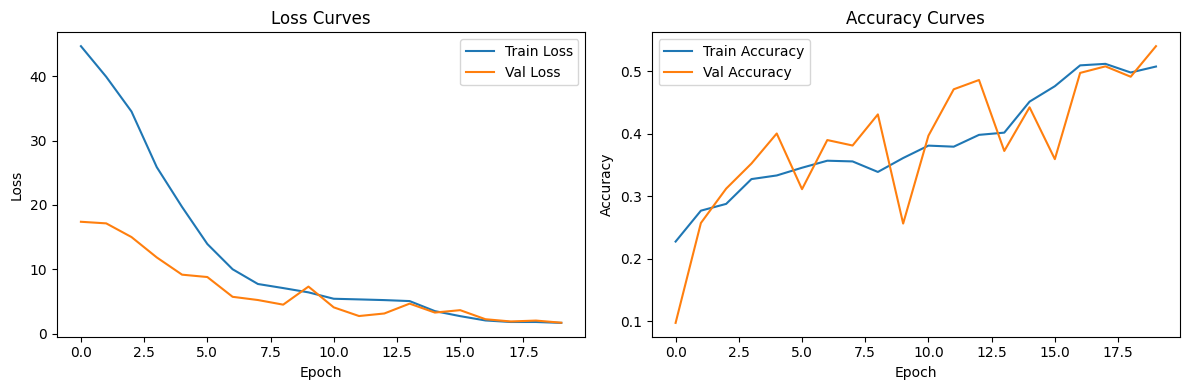

In [34]:
# Training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Handle class imbalance with class weights
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_int), y=y_train_int
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weight_dict)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Plot training curves
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test Loss: 1.7246
Test Accuracy: 0.5533
Weighted Precision: 0.5677
Weighted Recall: 0.5533
Weighted F1-score: 0.5432

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.78      0.73      0.75        81
  Food_Waste       0.48      0.73      0.58       150
       Glass       0.50      0.62      0.55       113
       Metal       0.67      0.31      0.42       150
       Other       0.54      0.40      0.46       151
       Paper       0.55      0.39      0.45       155
     Plastic       0.56      0.66      0.60       344

    accuracy                           0.55      1144
   macro avg       0.58      0.55      0.55      1144
weighted avg       0.57      0.55      0.54      1144



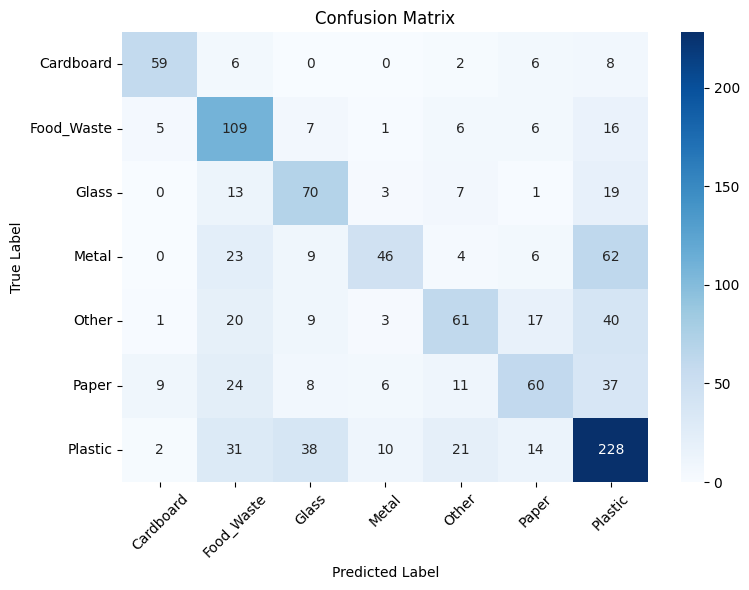

In [35]:
# Evaluate on the test set; display suitable metrics
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred_probs = model.predict(test_ds, verbose=0)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_true, y_test_pred, average='weighted', zero_division=0
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [36]:
# Define augmentation steps to augment images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
    tf.keras.layers.Lambda(lambda x: tf.clip_by_value(tf.image.random_brightness(x, max_delta=0.10), 0.0, 1.0)),
    GaussianNoise(0.02),
])

print(data_augmentation)

<Sequential name=sequential_5, built=False>


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [37]:
# Create a function to augment the images
AUTOTUNE = tf.data.AUTOTUNE

def create_augmented_dataset(X_data, y_data, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X_data, y_data))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_data), seed=SEED)
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [38]:
# Create the augmented training dataset
train_aug_ds = create_augmented_dataset(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_aug_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(train_aug_ds)
print(val_aug_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float64, name=None))>


##### **4.1.2**

Train the model on the new augmented dataset.

In [39]:
# Train the model using augmented images
aug_model = tf.keras.models.clone_model(model)
aug_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_model.fit(
    train_aug_ds,
    validation_data=val_aug_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_model.evaluate(test_ds, verbose=0)
print(f"Augmented Model - Test Loss: {aug_test_loss:.4f}")
print(f"Augmented Model - Test Accuracy: {aug_test_acc:.4f}")

aug_pred_probs = aug_model.predict(test_ds, verbose=0)
aug_pred = np.argmax(aug_pred_probs, axis=1)
aug_true = np.argmax(y_test, axis=1)
aug_precision, aug_recall, aug_f1, _ = precision_recall_fscore_support(
    aug_true, aug_pred, average='weighted', zero_division=0
)
print(f"Augmented Weighted Precision: {aug_precision:.4f}")
print(f"Augmented Weighted Recall: {aug_recall:.4f}")
print(f"Augmented Weighted F1-score: {aug_f1:.4f}")

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 119s 690ms/step - accuracy: 0.2177 - loss: 48.4992 - val_accuracy: 0.1696 - val_loss: 14.1282 - learning_rate: 0.0010
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 815s 5s/step - accuracy: 0.2353 - loss: 45.1134 - val_accuracy: 0.2343 - val_loss: 19.4031 - learning_rate: 0.0010
Epoch 3/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1112s 7s/step - accuracy: 0.2495 - loss: 39.0165 - val_accuracy: 0.2675 - val_loss: 18.3470 - learning_rate: 0.0010
Epoch 4/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - accuracy: 0.2617 - loss: 27.8851 - val_accuracy: 0.3365 - val_loss: 9.3546 - learning_rate: 5.0000e-04
Epoch 5/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.2693 - loss: 22.0695 - val_accuracy: 0.3864 - val_loss: 8.0552 - learning_rate: 5.0000e-04
Epoch 6/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.2667 - loss: 19.0399 - val_accuracy: 0.3427 - val_loss: 8.0898 - learning_rate: 5.0000e-04
Epoch 7/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/s

In [40]:
# Configuration comparison summary (baseline vs augmented)
config_comparison = pd.DataFrame([
    {
        'Configuration': f'Baseline {model_name} (with class weights)',
        'Epochs': 20,
        'Test Accuracy': round(float(test_acc), 4),
        'Test Loss': round(float(test_loss), 4),
        'Weighted Precision': round(float(precision), 4),
        'Weighted Recall': round(float(recall), 4),
        'Weighted F1': round(float(f1), 4)
    },
    {
        'Configuration': 'CNN with augmentation + class weights',
        'Epochs': 15,
        'Test Accuracy': round(float(aug_test_acc), 4),
        'Test Loss': round(float(aug_test_loss), 4),
        'Weighted Precision': round(float(aug_precision), 4),
        'Weighted Recall': round(float(aug_recall), 4),
        'Weighted F1': round(float(aug_f1), 4)
    }
])

print(config_comparison)

                              Configuration  Epochs  Test Accuracy  Test Loss  \
0  Baseline simple_cnn (with class weights)      20         0.5533     1.7246   
1     CNN with augmentation + class weights      15         0.3776     2.6182   

   Weighted Precision  Weighted Recall  Weighted F1  
0              0.5677           0.5533       0.5432  
1              0.4861           0.3776       0.3893  


## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* **Conclusion**
  * The pipeline was completed end-to-end: image loading, quality checks, RGB conversion, normalization, resizing to 128 x 128, label encoding, stratified splitting, CNN training, and multi-metric evaluation.
  * The dataset contains 7,625 images across 7 classes, with noticeable imbalance (Plastic highest, Cardboard lowest), which justifies using class weights during training.

* **Quantitative outcomes**
  * Baseline simple CNN + class weights (20 epochs): Accuracy = 0.5533, Loss = 1.7246, Weighted Precision = 0.5677, Weighted Recall = 0.5533, Weighted F1 = 0.5432.
  * Augmented CNN + class weights (15 epochs): Accuracy = 0.3776, Loss = 2.6182, Weighted Precision = 0.4861, Weighted Recall = 0.3776, Weighted F1 = 0.3893.

* **Interpretation and insights**
  * For this evaluation setup, the baseline model outperformed the augmented model, indicating that the current augmentation settings are too strong or not well matched to the data distribution.
  * Performance is moderate overall, suggesting the model learns meaningful waste features but still struggles with some classes due to overlap and imbalance.

* **Business relevance**
  * A CNN-based solution is feasible for automated waste segregation and can support faster sorting with reduced manual effort.
  * To improve operational reliability, class-wise performance should be raised before deployment in smart bins/sorting facilities.

* **Assumptions and next steps**
  * Assumptions: single-label image classification; folder names are ground-truth labels; 70/15/15 stratified split is appropriate.
  * Next steps: tune augmentation intensity, test the VGG-like architecture fully, and add per-class balancing/oversampling to improve minority-class recall.